In [1]:
%load_ext autoreload
%autoreload 2

import os
import warnings
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import seaborn as sns

import tools.particle_swarm_optimization as pso
import tools.particle_swarm_optimization_plot as pso_plt
import tools.peristimulus_time_histogram as psth

warnings.filterwarnings("ignore")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:13:33

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [95]:
# calculo cantidad de sinapsis

N_scaling, K_scaling = 0.1, 0.1

# internas
conn_probs = np.array(
        [
            [0.1009, 0.1689, 0.0437, 0.0818, 0.0323, 0.,     0.0076, 0.],       # L23E
            [0.1346, 0.1371, 0.0316, 0.0515, 0.0755, 0.,     0.0042, 0.],       # L23I
            [0.0077, 0.0059, 0.0497, 0.135,  0.0067, 0.0003, 0.0453, 0.],       # L4E
            [0.0691, 0.0029, 0.0794, 0.1597, 0.0033, 0.,     0.1057, 0.],       # L4I
            [0.1004, 0.0622, 0.0505, 0.0057, 0.0831, 0.3726, 0.0204, 0.],       # L5E
            [0.0548, 0.0269, 0.0257, 0.0022, 0.06,   0.3158, 0.0086, 0.],       # L5I
            [0.0156, 0.0066, 0.0211, 0.0166, 0.0572, 0.0197, 0.0396, 0.2252],   # L6E
            [0.0364, 0.001,  0.0034, 0.0005, 0.0277, 0.008,  0.0658, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )

conn_probs_v2= np.array(
        [
            [0.1309, 0.1789, 0.0637, 0.0918, 0.0423, 0.,     0.0096, 0.],       # L23E
            [0.1646, 0.1471, 0.0416, 0.0615, 0.0855, 0.,     0.0052, 0.],       # L23I
            [0.0087, 0.0069, 0.0597, 0.155,  0.0087, 0.0003, 0.0553, 0.],       # L4E
            [0.0691, 0.0039, 0.0894, 0.1697, 0.0043, 0.,     0.1157, 0.],       # L4I
            [0.1004, 0.0722, 0.0605, 0.0077, 0.0831, 0.3726, 0.0304, 0.],       # L5E
            [0.0548, 0.0369, 0.0457, 0.0032, 0.06,   0.3158, 0.0126, 0.],       # L5I
            [0.0156, 0.0086, 0.0411, 0.0266, 0.0572, 0.0197, 0.0696, 0.2252],   # L6E
            [0.0364, 0.002,  0.0044, 0.0025, 0.0377, 0.008,  0.0758, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )


print('****************')
print('Synap internas')
full_num_neurons = np.array([20683, 5834, 21915, 5479, 4850, 1065, 14395, 2948])
full_num_neurons_v2 = np.array([22051,  6219, 11421, 2855, 4461, 979,  13966, 2859])

prod = np.outer(full_num_neurons, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)
syn_int = np.round(full_syn_sum/full_num_neurons)

print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
syn_sum = np.round(num_synapses).astype(int).sum(axis=1)
num_neurons = np.round(full_num_neurons*N_scaling).astype(int)
syn_int = np.round(syn_sum/num_neurons)

print(syn_int)



print('****************')
print('Synap thalamicas')

conn_probs_th = np.array([0.0, 0.0, 0.0983, 0.0619, 0.0, 0.0, 0.0512, 0.0196])
prod = np.outer(902, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs_th) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int)
syn_int = np.round(full_syn_sum/full_num_neurons)
print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
syn_sum = np.round(num_synapses).astype(int)
syn_int = np.round(syn_sum/num_neurons)
print(syn_int)


print('****************')
print('Synap Lateral')


conn_probs = np.array(
                [[0.06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L23E
                [0.03, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L23I
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L4E
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L4I
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L5E
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L5I
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],      # L6E
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])    # L6I
                # L2E  L2I  L4E  L4I  L5E  L5I  L6E  L6I}

prod = np.outer(full_num_neurons, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)
syn_int = np.round(full_syn_sum/full_num_neurons)

print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
syn_sum = np.round(num_synapses).astype(int).sum(axis=1)
syn_int = np.round(syn_sum/num_neurons)

print(syn_int)



print('****************')
print('Synap FF')


conn_probs= np.array(
            [[0.0,    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L23E
             [0.0,    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # L23I
             [0.1,    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L4E
             [0.065,  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L4I
             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L5E
             [0.0,   0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L5I
             [0.1689, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],    # L6E
             [0.1371, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])


prod = np.outer(full_num_neurons, full_num_neurons_v2)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)
syn_int = np.round(full_syn_sum/full_num_neurons_v2)

print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
num_neurons_v2 = np.round(full_num_neurons_v2*N_scaling).astype(int)

syn_sum = np.round(num_synapses).astype(int).sum(axis=1)
syn_int = np.round(syn_sum/num_neurons_v2)

print(syn_int)

print('****************')
print('Synap FB')


conn_probs = np.array(
            [[0.0, 0.0, 0.0, 0.0, 0.06, 0.0, 0.06, 0.0],     # L23E
             [0.0, 0.0, 0.0, 0.0, 0.03, 0.0, 0.03, 0.0],     # L23I
             [0.0, 0.0, 0.0, 0.0, 0.0,  0.0, 0.0,  0.0],     # L4E
             [0.0, 0.0, 0.0, 0.0, 0.0,  0.0, 0.0,  0.0],     # L4I
             [0.0, 0.0, 0.0, 0.0, 0.06, 0.0, 0.06, 0.0],     # L5E
             [0.0, 0.0, 0.0, 0.0, 0.03, 0.0, 0.03, 0.0],     # L5I
             [0.0, 0.0, 0.0, 0.0, 0.02, 0.0, 0.02,  0.0],     # L6E
             [0.0, 0.0, 0.0, 0.0, 0.01, 0.0, 0.01,  0.0]])

prod = np.outer(full_num_neurons_v2, full_num_neurons)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)
syn_int = np.round(full_syn_sum/full_num_neurons)

print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)
syn_sum = np.round(num_synapses).astype(int).sum(axis=1)
syn_int = np.round(syn_sum/num_neurons)

print(syn_int)

print('****************')
print('Synap internas V2')

conn_probs= np.array(
        [
            [0.1309, 0.1789, 0.0637, 0.0918, 0.0423, 0.,     0.0096, 0.],       # L23E
            [0.1646, 0.1471, 0.0416, 0.0615, 0.0855, 0.,     0.0052, 0.],       # L23I
            [0.0087, 0.0069, 0.0597, 0.155,  0.0087, 0.0003, 0.0553, 0.],       # L4E
            [0.0691, 0.0039, 0.0854, 0.1647, 0.0043, 0.,     0.1077, 0.],       # L4I
            [0.1004, 0.0722, 0.0605, 0.0077, 0.0831, 0.3726, 0.0304, 0.],       # L5E
            [0.0548, 0.0369, 0.0457, 0.0032, 0.06,   0.3158, 0.0126, 0.],       # L5I
            [0.0156, 0.0086, 0.0411, 0.0266, 0.0572, 0.0197, 0.0696, 0.2252],   # L6E
            [0.0364, 0.002,  0.0044, 0.0025, 0.0377, 0.008,  0.0758, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )*0.8

prod = np.outer(full_num_neurons_v2, full_num_neurons_v2)
full_num_synapses = np.log(1. - conn_probs) / np.log((prod - 1.) / prod)

full_syn_sum = np.round(full_num_synapses).astype(int).sum(axis=1)
syn_int = np.round(full_syn_sum/full_num_neurons_v2)

print(syn_int)

num_synapses = np.round(full_num_synapses * N_scaling * K_scaling).astype(int)

syn_sum = np.round(num_synapses).astype(int).sum(axis=1)
num_neurons = np.round(full_num_neurons_v2*N_scaling).astype(int)
syn_int = np.round(syn_sum/num_neurons)

print(syn_int)


print('****************')
print('Ext indegreees')

K_ext = np.array([1600, 1500, 2100, 1900, 2000, 1900, 2900, 2100])

ext_indegrees = np.round(K_ext * K_scaling).astype(int)
print(ext_indegrees)

K_ext = np.array([1700, 1500, 1550, 1420, 2050, 1900, 2800, 2100])
ext_indegrees = np.round(K_ext * K_scaling).astype(int)
print(ext_indegrees)


****************
Synap internas
[4995. 5285. 2806. 5888. 4944. 2736. 2564. 2434.]
[500. 529. 281. 589. 494. 275. 256. 243.]
****************
Synap thalamicas
[[ 0.  0. 93. 58.  0.  0. 47. 18.]]
[[0. 0. 9. 6. 0. 0. 5. 2.]]
****************
Synap Lateral
[1280.  630.    0.    0.    0.    0.    0.    0.]
[128.  63.   0.   0.   0.   0.   0.   0.]
****************
Synap FF
[   0.    0. 4458. 2844.    0.    0. 4205. 3353.]
[  0.   0. 446. 284.   0.   0. 420. 335.]
****************
Synap FB
[1270.  625.    0.    0. 1095.  539.  377.  188.]
[127.  63.   0.   0. 110.  54.  38.  19.]
****************
Synap internas V2
[4476. 4797. 1789. 3759. 3798. 2254. 2356. 2075.]
[448. 480. 179. 375. 380. 225. 235. 207.]
****************
Ext indegreees
[160 150 210 190 200 190 290 210]
[170 150 155 142 205 190 280 210]


[[0.06 0.   4.  ]
 [0.   0.03 4.  ]]


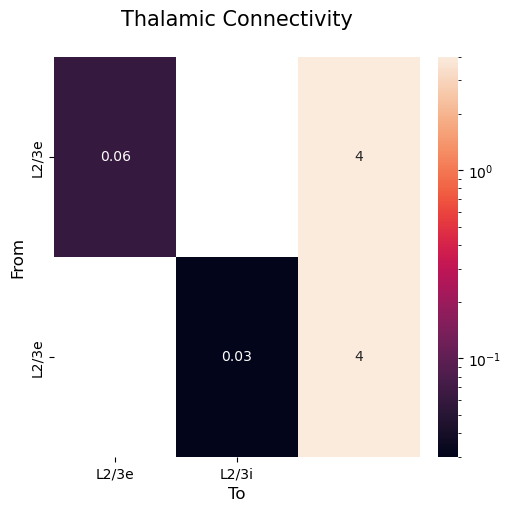

In [ ]:
# mapa de calor de la matriz de conectividad

prob = np.array(
        [
            [0.1009, 0.1689, 0.0437, 0.0818, 0.0323, 0.,     0.0076, 0.],       # L23E
            [0.1346, 0.1371, 0.0316, 0.0515, 0.0755, 0.,     0.0042, 0.],       # L23I
            [0.0077, 0.0059, 0.0497, 0.135,  0.0067, 0.0003, 0.0453, 0.],       # L4E
            [0.0691, 0.0029, 0.0794, 0.1597, 0.0033, 0.,     0.1057, 0.],       # L4I
            [0.1004, 0.0622, 0.0505, 0.0057, 0.0831, 0.3726, 0.0204, 0.],       # L5E
            [0.0548, 0.0269, 0.0257, 0.0022, 0.06,   0.3158, 0.0086, 0.],       # L5I
            [0.0156, 0.0066, 0.0211, 0.0166, 0.0572, 0.0197, 0.0396, 0.2252],   # L6E
            [0.0364, 0.001,  0.0034, 0.0005, 0.0277, 0.008,  0.0658, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )

prob_v2 = np.array(
        [
            [0.1309, 0.1789, 0.0637, 0.0918, 0.0423, 0.,     0.0096, 0.],       # L23E
            [0.1646, 0.1471, 0.0416, 0.0615, 0.0855, 0.,     0.0052, 0.],       # L23I
            [0.0087, 0.0069, 0.0597, 0.155,  0.0087, 0.0003, 0.0553, 0.],       # L4E
            [0.0691, 0.0039, 0.0854, 0.1647, 0.0043, 0.,     0.1077, 0.],       # L4I
            [0.1004, 0.0722, 0.0605, 0.0077, 0.0831, 0.3726, 0.0304, 0.],       # L5E
            [0.0548, 0.0369, 0.0457, 0.0032, 0.06,   0.3158, 0.0126, 0.],       # L5I
            [0.0156, 0.0086, 0.0411, 0.0266, 0.0572, 0.0197, 0.0696, 0.2252],   # L6E
            [0.0364, 0.002,  0.0044, 0.0025, 0.0377, 0.008,  0.0758, 0.1443],  # L6I
             # L23E   L23I     L4E      L4I     L5E    L5I    L6E      L6I
        ]
    )

#prob_v2 = prob

# print(np.max(prob))
# probb = np.round(prob_v2, 3)
# print(probb)
# ax_lab = ['L23E', 'L23I', 'L4E', 'L4I', 'L5E', 'L5I', 'L6E', 'L6I']

# sns.heatmap(prob_v2, annot=True, norm=LogNorm(), xticklabels=ax_lab, yticklabels=ax_lab, vmin=0, vmax=0.3726)
# plt.title("Microcircuit Connectivity Matrix in V2\n", fontsize=15)
# plt.xlabel('From',fontsize=12)
# plt.ylabel('To',fontsize=12)

# plt.show()

fig, ax = plt.subplots(layout='constrained', figsize=(5,5), sharex=True)

prob_thal = np.array([ [0.06, 0.03], [0.0, 0.03]])  # L6I
probb = np.round(prob_thal, 3)
print(probb)
ax_lab = ['L2/3e', 'L2/3i']
ay_lab = ['L2/3e', 'L2/3e']

sns.heatmap(prob_thal, annot=True, norm=LogNorm(), xticklabels=ax_lab, yticklabels=ay_lab, robust=True, vmin=0, vmax=0.3726)
plt.title("Thalamic Connectivity\n", fontsize=15)
plt.xlabel('To',fontsize=12)
plt.ylabel('From',fontsize=12)

plt.show()


  Only spikes of neurons in steps of 4 are shown.


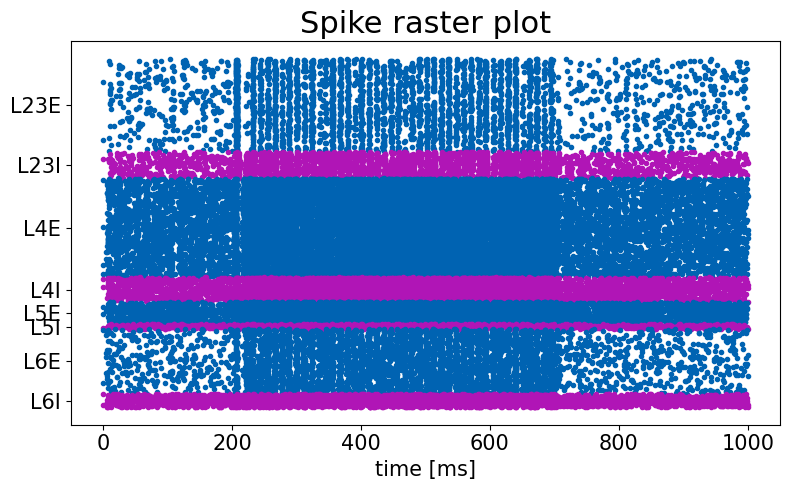

In [15]:
## Raster plot y firing rate
## por simulación

from utils import helpers
import scipy.stats as stats

data_path = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20250130153136/'

populations = ['L23E', 'L23I', 'L4E', 'L4I', 'L5E', 'L5I', 'L6E', 'L6I']
names = ['CMC V1 ( l )', 'CMC V1 ( \\ )', 'CMC V1 ( - )', 'CMC V1 ( / )', 'CMC V2']
#names = ['CMC V1 ( l )', 'CMC V1 ( \\ )', 'CMC V1 ( - )', 'CMC V1 ( / )']
names = ['CMC V1']
#names = ['']

all_pops = []

for i in names:
    all_pops += list(map(lambda pop: f"{pop}",populations))

t_sim = 1000

if False:
    firing_rates_interval = np.array([0, t_sim])

    print('Interval to compute firing rates: {} ms'.format(firing_rates_interval))
    helpers.firing_rates(
        data_path,
        'spike_recorder',
        0,
        t_sim)
    helpers.boxplot(data_path, all_pops, 'firing_rate_',  False, True, names)

if True:
    id_sim = data_path.split("/")[-1]
    helpers.plot_raster(
        data_path,
        'spike_recorder',
        0,
        t_sim,
        0.4,
        all_pops,
        id_sim)


######################## test estadistico

if False:

    data_path1 = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Est 4 mcc 4000 ms/'
    data_path2 = '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Est 5 mcc 4000 ms/'

    pval_1, pval_2 = [], []

    for i in range(8):
        g1 = np.loadtxt(os.path.join(data_path1, ('rate' + str(i) + '.dat')))
        g2 = np.loadtxt(os.path.join(data_path2, ('rate' + str(i) + '.dat')))
        g3 = np.loadtxt(os.path.join(data_path2, ('rate' + str(i+32) + '.dat')))

        n, p = stats.mannwhitneyu(g1,g2)
        pval_1.append(p)

        n, p = stats.mannwhitneyu(g1,g3)
        pval_2.append(p)

    # Redondear a 2 decimales
    pval_1r = [round(valor, 4) for valor in pval_1]  
    pval_2r = [round(valor, 4) for valor in pval_2]  
    print(pval_1r)
    print(pval_2r)
        

In [206]:
# PSTH carpeta
folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/ECRF_V2_sinlat_2/')
#folder_path = '/home/samuelmr/Escritorio/results/09_28/result3_4'


t_sim = 1500
l_bin = 500
#psth.PSTH_folders_data(folder_path, 0.2, t_sim, l_bin) 

#l_bin = 50
psth.PSTH_folders_data(folder_path, 0.2, t_sim, l_bin) 

if False:
    psth.PSTH_figure(folder_path, t_sim, l_bin, 0)
    psth.PSTH_figure(folder_path, t_sim, l_bin, 1)
    psth.PSTH_figure(folder_path, t_sim, l_bin, 2)
    psth.PSTH_figure(folder_path, t_sim, l_bin, 3)

    psth.PSTH_figure(folder_path, t_sim, l_bin, 4)
    psth.PSTH_figure(folder_path, t_sim, l_bin, 5)
    #psth.PSTH_plot_tog(folder_path, t_sim, l_bin)

    #psth.PSTH_plot(folder_path, 1500, l_bin)



In [15]:
# Calculo estadistico entre 3 etapas

from utils import helpers
import scipy.stats as stats

path = os.path.join(os.getcwd(), 'results/potjans_diesmann/ECRF_v2_20hz_10hz')

l_bin = 50
t_sim = 1500


psth.PSTH_folders_data(path, 0.4, t_sim, l_bin) 


cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

psth_data = pd.read_csv(os.path.join(path, 'psth_'+str(l_bin)+'.csv'), header=None, names=names)
subset = psth_data[(psth_data['layer'].isin(['2/3c', '4c', '5c', '6c']))][names[3:]].values

# Inicializamos listas para almacenar los resultados
p_values = []
t_statistics = []
p_values2 = []
t_statistics2 = []

l_3 = int(t_sim/l_bin/3)
for i in range(10):
    for j in range(8):
        
        pre = subset[i*8+j][2:l_3]
        post1 = subset[i*8+j][l_3+2:2*l_3]
        post2 = subset[i*8+j][2*l_3+2:3*l_3]

        t_stat, p_val = stats.wilcoxon(pre, post2)
        p_values.append(p_val)
        t_statistics.append(t_stat)

        t_stat, p_val = stats.wilcoxon(post1, post2)
        p_values2.append(p_val)
        t_statistics2.append(t_stat)
        



for i in range(8):
    
    if np.std((p_values[i::8])) < 0.05:
        print('si')
    else:
        print('no')
    print('  '+str( np.std((p_values[i::8]))))





FileNotFoundError: [Errno 2] No such file or directory: '/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v2_20hz_10hz'

-0.1874206532295815
6.532704763366517


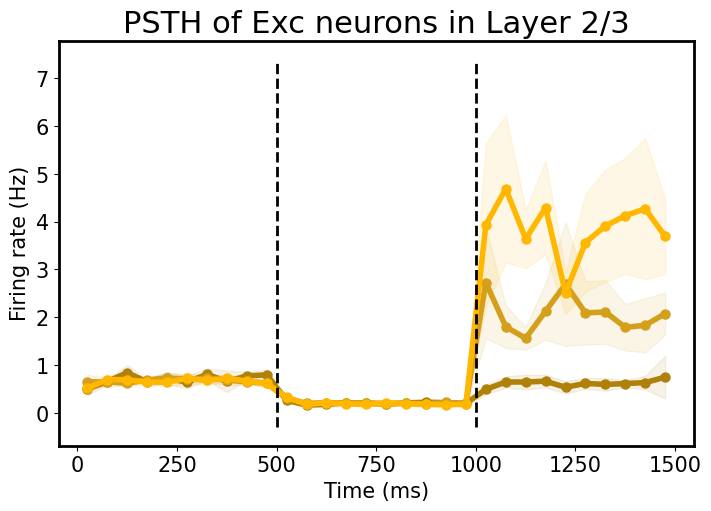

In [10]:
# PSTH figuras varias curvas

folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/Av_2_res/ECRF_v22_20hz_30hz/')
t_sim = 1500
l_bin = 50

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))

#################
if True:
    L = '2/3'
    subset = mean_data[(mean_data['type'] == 'exc') & (mean_data['layer'] == L+'v22')][names[3:]].values

    fig, ax = plt.subplots(layout='constrained', figsize=(7,5), sharex=True)

    color = ['#008CAD','#0063B2','#0046B6','#0028BA']
    color = ['#112366','#152A77','#1435AD','#1E4EFF'] #azul 2.0
    color = ['#152A77','#1435AD','#1E4EFF'] #azul 2.0
    #color = ['#5F1AFF','#BF0AFF','#FF0079'] #rosa morado
    
    #color = ['#9DF000','#64E700','#00D20E'] #verde    
    color = ['#098A11','#00C90D','#00FF11'] #verde    

    #color = ['#F60018','#FF3900','#FF6A00'] #naranjo
    #color = ['#AF4F0B','#D95A00','#FF6A00'] #naranjo

    #color = ['#FF8700','#FFA100','#FFB700'] #amarillo
    color = ['#AF810B','#D4A01C','#FFB700'] #amarillo


    #color = ['#CD0074','#FF0000','#FF7400','#FFAA00','#FFD300','#FFFF00']
    for i in range(0, len(subset),2):
    
        y = subset[i]
        ci = subset[i+1]

        ax.plot(bin_centers, y, '.-',lw=4, color=color[int(i/2)], markersize=13)
        ax.fill_between(bin_centers, (y-ci/1.5), (y+ci/1.5), color=color[int(i/2)], alpha=.1)

    bot, top = ax.get_ylim()  # return the current ylim
    print(bot)
    print(top)
    bot = -0.3
    top = 7.4
    ax.plot([500, 500], [bot, top], 'k--', lw=2)
    ax.plot([1000, 1000], [bot, top], 'k--', lw=2)

    plt.xlabel('Time (ms)',fontsize=15)
    plt.ylabel('Firing rate (Hz)',fontsize=15)
    plt.title('PSTH of Exc neurons in Layer '+L,fontsize=22)
    plt.xticks(fontsize = 15) 
    plt.yticks(fontsize = 15) 
    plt.xticks([0, 250, 500, 750, 1000, 1250, 1500],[0, 250, 500, 750, 1000, 1250, 1500])

    for spine in ax.spines.values():
        spine.set_linewidth(2) 
    plt.show()

####################
if False:
    L = '4'
    subset = mean_data[(mean_data['type'] == 'exc') & (mean_data['layer'].isin([L+'a', L+'c', L+'v2']))][names[3:]].values
    #subset = mean_data[(mean_data['type'] == 'exc') & (mean_data['layer'].isin(['4a', '4c']))][names[3:]].values


    fig, ax = plt.subplots(layout='constrained', figsize=(7,5), sharex=True)

    y, ci= subset[2], subset[3]
    ax.plot(bin_centers, y, '.-',lw=4, color='#00FF11', markersize=13)
    ax.fill_between(bin_centers, (y-ci), (y+ci), color='#00FF11', alpha=.1)

    y, ci= subset[0], subset[1]
    ax.plot(bin_centers, y, '.-', lw=4, color='#1E4EFF', markersize=13)
    ax.fill_between(bin_centers, (y-ci), (y+ci), color='#1E4EFF', alpha=.1)

    y, ci= subset[4], subset[5]
    ax.plot(bin_centers, y, '.-',lw=4, color='#FF6A00', markersize=13)
    ax.fill_between(bin_centers, (y-ci/1.5), (y+ci/1.5), color='#FF6A00', alpha=.1)

    # y, ci= subset[4], subset[5]
    # ax.plot(bin_centers, y, '.-',lw=4, color='#FF6A00', markersize=2)
    # ax.fill_between(bin_centers, (y-ci), (y+ci), color='#FF6A00', alpha=.1)
    
    
    bot, top = ax.get_ylim()  # return the current ylim  color='#FF6A00'
    ax.plot([500, 500], [bot, top], 'k--')
    ax.plot([1000, 1000], [bot, top], 'k--')

    plt.xlabel('Time (ms)',fontsize=15)
    plt.ylabel('Firing rate (Hz)',fontsize=15)
    plt.title('PSTH of Exc neurons in Layer '+L,fontsize=22)
    plt.xticks(fontsize = 15) 
    plt.yticks(fontsize = 15) 
    plt.xticks([0, 250, 500, 750, 1000, 1250, 1500],[0, 250, 500, 750, 1000, 1250, 1500])

    for spine in ax.spines.values():
        spine.set_linewidth(2) 

    plt.show()

4.45 \pm\,0.21 & 21.8 \pm\,1.32 & 23.22 \pm\,0.97 & 23.85 \pm\,0.87 & 22.69 \pm\,0.85 & 
0.10546875
0.01953125
0.232421875
0.013671875
0.001953125
0.083984375


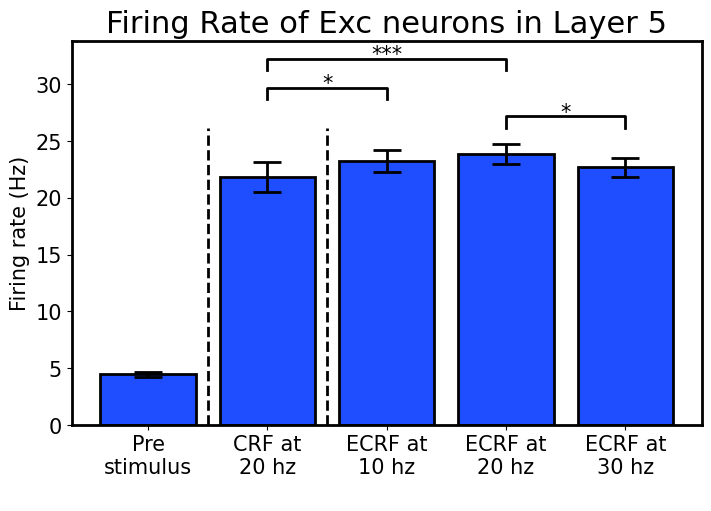

In [244]:
# grafico de barras (ECRF)

from utils import helpers
import scipy.stats as stats
from itertools import combinations


l_bin = 500
t_sim = 1500
l_3 = int(t_sim/l_bin/3)
group = '5a'
color = '#1E4EFF'
#color = '#0EEC1C'
#color = '#FF6A00'
#color = '#FFB700'

cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)


path = os.path.join(os.getcwd(), 'results/potjans_diesmann/Av_2_res/ECRF_v22_20hz_10hz')
psth.PSTH_folders_data(path, 0.2, t_sim, l_bin) 
psth_data = pd.read_csv(os.path.join(path, 'psth_'+str(l_bin)+'.csv'), header=None, names=names)
subset = psth_data[(psth_data['type'] == 'exc') & (psth_data['layer'].isin([group]))][names[3:]].values
pre1, crf1, ecrf1 = [], [], []
for i in range(10):
    pre1 = np.concatenate((pre1, subset[i][0*l_3:1*l_3]), axis = 0) 
    crf1 = np.concatenate((crf1, subset[i][1*l_3:2*l_3]), axis = 0) 
    ecrf1 = np.concatenate((ecrf1, subset[i][2*l_3:3*l_3]), axis = 0) 

path = os.path.join(os.getcwd(), 'results/potjans_diesmann/Av_2_res/ECRF_v22_20hz_20hz')
psth.PSTH_folders_data(path, 0.2, t_sim, l_bin) 
psth_data = pd.read_csv(os.path.join(path, 'psth_'+str(l_bin)+'.csv'), header=None, names=names)
subset = psth_data[(psth_data['type'] == 'exc') & (psth_data['layer'].isin([group]))][names[3:]].values
pre2, crf2, ecrf2 = [], [], []
for i in range(10):
    pre2 = np.concatenate((pre2, subset[i][0*l_3:1*l_3]), axis = 0) 
    crf2 = np.concatenate((crf2, subset[i][1*l_3:2*l_3]), axis = 0) 
    ecrf2 = np.concatenate((ecrf2, subset[i][2*l_3:3*l_3]), axis = 0) 

path = os.path.join(os.getcwd(), 'results/potjans_diesmann/Av_2_res/ECRF_v22_20hz_30hz')
psth.PSTH_folders_data(path, 0.2, t_sim, l_bin) 
psth_data = pd.read_csv(os.path.join(path, 'psth_'+str(l_bin)+'.csv'), header=None, names=names)
subset = psth_data[(psth_data['type'] == 'exc') & (psth_data['layer'].isin([group]))][names[3:]].values
pre3, crf3, ecrf3 = [], [], []
for i in range(10):
    pre3 = np.concatenate((pre3, subset[i][0*l_3:1*l_3]), axis = 0) 
    crf3 = np.concatenate((crf3, subset[i][1*l_3:2*l_3]), axis = 0) 
    ecrf3 = np.concatenate((ecrf3, subset[i][2*l_3:3*l_3]), axis = 0) 

###################### figure

fig, ax = plt.subplots(layout='constrained', figsize=(7,5), sharex=True)
 
position = [0, 1, 2, 3, 4]
meanbar = [np.mean(pre1), np.mean(crf3), np.mean(ecrf1), np.mean(ecrf2), np.mean(ecrf3)]
stdbar = [np.std(pre1), np.std(crf3), np.std(ecrf1), np.std(ecrf2), np.std(ecrf3)]
strmean = np.round(meanbar, 2)
strstd = np.round(stdbar, 2)

n_str = ''
for i in range(5):
    n_str = n_str + str(strmean[i]) + ' \pm\,' + str(strstd[i]) + ' & '

print(n_str)


plt.bar(position, meanbar, fc=color, ec='k', lw=2, capsize=5)
plt.errorbar(position, meanbar, yerr=stdbar, fmt=' ', capsize=10, capthick=2, elinewidth=2, ecolor='k') # elinewidth y ecolor

 # Statistical test for each group in the section
all_lists = [pre1, crf3, ecrf1, ecrf2, ecrf3]

all_data = np.concatenate(all_lists)
h, sig = (max(all_data))/25, False
y =  max(meanbar)+max(stdbar) + h
yy = y

el1 = [2,3,2,1,1,1]
el2 = [3,4,4,2,3,4]

for i in range(len(el1)):
    stat, pvalue = stats.wilcoxon(all_lists[el1[i]], all_lists[el2[i]])
    print(pvalue)

    # Plot and pimp my error
    if pvalue <= 0.05:
        x1, x2 = int(el1[i]), int(el2[i])
        plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='k')
        if pvalue <= 0.005:
            plt.text((x1+x2)*.5, y+h/2, '***', ha='center', va='bottom', color='k', size=15)
        elif pvalue <= 0.01:
            plt.text((x1+x2)*.5, y+h/2, '**', ha='center', va='bottom', color='k', size=15)
        else:
            plt.text((x1+x2)*.5, y+h/2, '*', ha='center', va='bottom', color='k', size=15)
        
        if i==0:
            continue
        y = y + 2.5*h

    elif i == 1 :#or i == 3:
        y = y + 2.5*h
    elif i == 3:
        y = y + h


bot, top = ax.get_ylim()  # return the current ylim
ax.plot([.5, .5], [bot, yy], 'k--', lw=2)
ax.plot([1.5, 1.5], [bot, yy], 'k--', lw=2)
#plt.ylim([bot,top])

#plt.xlabel('Time (ms)',fontsize=15)
plt.ylabel('Firing rate (Hz)',fontsize=15)
plt.title('Firing Rate of Exc neurons in Layer '+group[:-1],fontsize=22)
plt.xticks([0, 1, 2, 3, 4],['Pre\nstimulus\n', 'CRF at\n20 hz', 'ECRF at\n10 hz', 'ECRF at\n20 hz', 'ECRF at\n30 hz'])


plt.xticks(fontsize = 15) 
plt.yticks(fontsize = 15) 

for spine in ax.spines.values():
    spine.set_linewidth(2) 
plt.show()

    

/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Av_2_res/ECRF_v1_20hz_10hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Av_2_res/ECRF_v1_20hz_20hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Av_2_res/ECRF_v1_20hz_30hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Av_2_res/ECRF_v2_20hz_10hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Av_2_res/ECRF_v2_20hz_20hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Av_2_res/ECRF_v2_20hz_30hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Av_2_res/ECRF_v22_20hz_10hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Av_2_res/ECRF_v22_20hz_20hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/Av_2_res/ECRF_v22_20hz_30hz
100.0 \pm\,0.0 & 82.26 \pm\,3.82 &

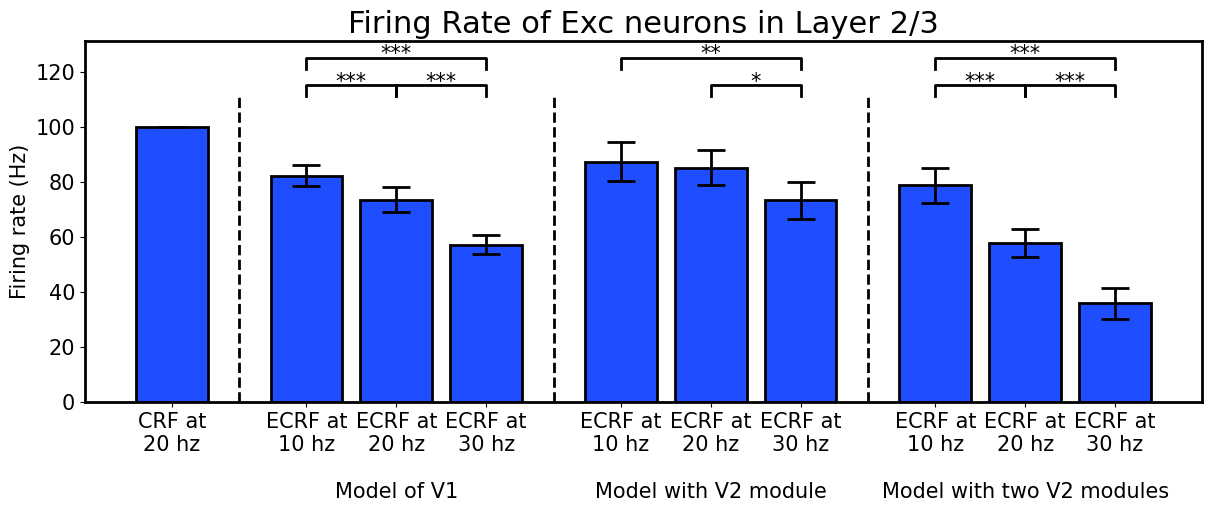

15433.800000000001


In [249]:
# gráfico de barras entre modelos

# grafico de barras (ECRF)

from utils import helpers
import scipy.stats as stats
from itertools import combinations


l_bin = 500
t_sim = 1500
l_3 = int(t_sim/l_bin/3)
groupx = '2/3v2'
color = '#1E4EFF'
#color = '#0EEC1C'
#color = '#FF6A00'

cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

data = [np.ones([10])*100]

for group in ['2/3a']:
    for fold in ['v1','v2','v22']:
        
        for ts in ['10', '20', '30']:

            path = os.path.join(os.getcwd(), 'results/potjans_diesmann/Av_2_res/ECRF_'+fold+'_20hz_'+ts+'hz')
            print(path)
            psth.PSTH_folders_data(path, 0.2, t_sim, l_bin) 
            psth_data = pd.read_csv(os.path.join(path, 'psth_'+str(l_bin)+'.csv'), header=None, names=names)
            subset = psth_data[(psth_data['type'] == 'exc') & (psth_data['layer'].isin([group]))][names[3:]].values 
            pre1, crf1, ecrf1 = [], [], []
                    
            for i in range(10):
                pre1 = subset[i][0*l_3:1*l_3]
                crf1 = subset[i][1*l_3:2*l_3]
                m = 100/(crf1-pre1)
                n = -m*pre1
                ecrf1 = np.concatenate((ecrf1,m*subset[i][2*l_3:3*l_3]+n), axis = 0)
            data.append(ecrf1)

    # if group == '2/3a':
    #     data.append(np.ones([10])*100)

data = np.array(data)

###################### figure
if True:

    fig, ax = plt.subplots(layout='constrained', figsize=(np.size(data,0)+2,5), sharex=True)
    
    meanbar = np.mean(data, axis=1)
    stdbar = np.std(data, axis=1)

    strmean = np.round(meanbar, 2)
    strstd = np.round(stdbar, 2)

    n_str = ''
    for i in range(len(meanbar)):
        n_str = n_str + str(strmean[i]) + ' \pm\,' + str(strstd[i]) + ' & '

    print(n_str)
    xbar = [-0.5,1,2,3,4.5,5.5,6.5,8,9,10]
    colors = ['#1E4EFF','#1E4EFF','#1E4EFF','#1E4EFF','#1E4EFF','#1E4EFF','#1E4EFF','#1E4EFF','#1E4EFF','#1E4EFF']

    plt.bar(xbar, meanbar, color=colors, ec='k', lw=2, capsize=5)
    plt.errorbar(xbar, meanbar, yerr=stdbar, fmt=' ', capsize=10, capthick=2, elinewidth=2, ecolor='k') # elinewidth y ecolor

    #plt.bar(range(np.size(data,0)), meanbar, fc=color, ec='k', lw=2, capsize=5)
    #plt.errorbar(range(np.size(data,0)), meanbar, yerr=stdbar, fmt=' ', capsize=10, capthick=2, elinewidth=2, ecolor='k') # elinewidth y ecolor

    h, sig = (np.max(data))/25, False
    y =  max(meanbar)+max(stdbar) + h
    yy = y

    el1 = [1,2,4,5,7,8,1,4,7]
    el2 = [2,3,5,6,8,9,3,6,9]

    # el1 = [1,2,4,5,1,4]
    # el2 = [2,3,5,6,3,6]
    # el1 = [1,2,5,6,1,5]
    # el2 = [2,3,6,7,3,7]

    #el1 = [1,2,1]
    # el2 = [2,3,3]

    for i in range(len(el1)):
        stat, pvalue = stats.wilcoxon(data[el1[i]], data[el2[i]])

        # Plot and pimp my error
        if pvalue <= 0.05:
            x1, x2 = int(el1[i]), int(el2[i])
            if x1>=4:
                x1+=.5
                x2+=.5
            if x1>=7:
                x1+=.5
                x2+=.5
            plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='k')
            if pvalue <= 0.005:
                plt.text((x1+x2)*.5, y+h/2, '***', ha='center', va='bottom', color='k', size=15)
            elif pvalue <= 0.01:
                plt.text((x1+x2)*.5, y+h/2, '**', ha='center', va='bottom', color='k', size=15)
            else:
                plt.text((x1+x2)*.5, y+h/2, '*', ha='center', va='bottom', color='k', size=15)
            
        if i==5:
            y = y + 2.5*h


    bot, top = ax.get_ylim()  # return the current ylim
    ax.plot([.25, .25], [bot, yy], 'k--', lw=2)
    #ax.plot([3.5, 3.5], [bot, yy], 'k--', lw=2)   
    
    ax.plot([3.75, 3.75], [bot, yy], 'k--', lw=2)
    ax.plot([7.25, 7.25], [bot, yy], 'k--', lw=2)

    #plt.ylim([bot,top])

    #plt.xlabel('Time (ms)',fontsize=15)
    plt.ylabel('Firing rate (Hz)',fontsize=15)
    plt.title('Firing Rate of Exc neurons in Layer '+group[:-1],fontsize=22)
    plt.xticks(xbar,['CRF at\n20 hz',
       'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nModel of V1', 'ECRF at\n30 hz',
       'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nModel with V2 module', 'ECRF at\n30 hz',
       'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nModel with two V2 modules', 'ECRF at\n30 hz'])

    # plt.xticks(xbar,['CRF at\n20 hz',
    #     #'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nModel of V1', 'ECRF at\n30 hz',
    #     'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nV1 microcolumn', 'ECRF at\n30 hz',
    #     'CRF at\n20 hz',
    #     'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nV2 microcolumn', 'ECRF at\n30 hz'])


    plt.xticks(fontsize = 15) 
    plt.yticks(fontsize = 15) 

    for spine in ax.spines.values():
        spine.set_linewidth(2) 
    plt.show()
print(np.sum(np.array([20683, 5834, 21915, 5479, 4850, 1065, 14395, 2948])/5))

/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v22_20hz_10hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v22_20hz_20hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v22_20hz_30hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v22_20hz_10hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v22_20hz_20hz
/home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/ECRF_v22_20hz_30hz
100.0 \pm\,0.0 & 78.78 \pm\,6.4 & 57.74 \pm\,5.0 & 35.8 \pm\,5.63 & 100.0 \pm\,0.0 & 61.97 \pm\,12.25 & 37.55 \pm\,10.52 & 7.46 \pm\,3.59 & 


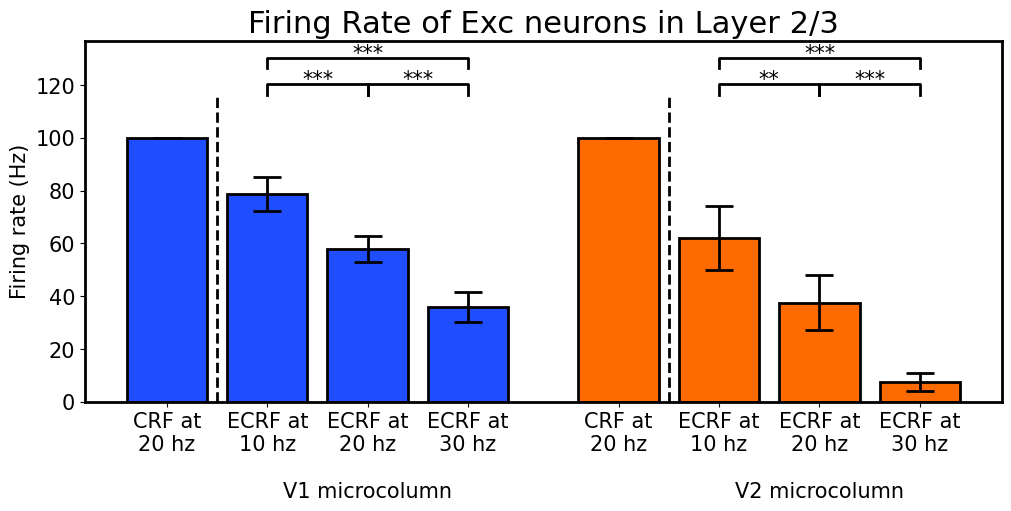

In [83]:
# gráfico de barras entre modelos

# grafico de barras (ECRF)

from utils import helpers
import scipy.stats as stats
from itertools import combinations


l_bin = 500
t_sim = 1500
l_3 = int(t_sim/l_bin/3)
groupx = '2/3v2'
color = '#1E4EFF'
#color = '#0EEC1C'
#color = '#FF6A00'

cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

data = [np.ones([10])*100]

for group in ['2/3a', '2/3v2']:
    for fold in ['v22']:
        
        for ts in ['10', '20', '30']:

            path = os.path.join(os.getcwd(), 'results/potjans_diesmann/ECRF_'+fold+'_20hz_'+ts+'hz')
            print(path)
            psth.PSTH_folders_data(path, 0.2, t_sim, l_bin) 
            psth_data = pd.read_csv(os.path.join(path, 'psth_'+str(l_bin)+'.csv'), header=None, names=names)
            subset = psth_data[(psth_data['type'] == 'exc') & (psth_data['layer'].isin([group]))][names[3:]].values 
            pre1, crf1, ecrf1 = [], [], []
                    
            for i in range(10):
                pre1 = subset[i][0*l_3:1*l_3]
                crf1 = subset[i][1*l_3:2*l_3]
                m = 100/(crf1-pre1)
                n = -m*pre1
                ecrf1 = np.concatenate((ecrf1,m*subset[i][2*l_3:3*l_3]+n), axis = 0)
            data.append(ecrf1)

    if group == '2/3a':
        data.append(np.ones([10])*100)

data = np.array(data)

###################### figure
if True:

    fig, ax = plt.subplots(layout='constrained', figsize=(np.size(data,0)+2,5), sharex=True)
    
    meanbar = np.mean(data, axis=1)
    stdbar = np.std(data, axis=1)

    strmean = np.round(meanbar, 2)
    strstd = np.round(stdbar, 2)

    n_str = ''
    for i in range(len(meanbar)):
        n_str = n_str + str(strmean[i]) + ' \pm\,' + str(strstd[i]) + ' & '

    print(n_str)
    xbar = [0,1,2,3,4.5,5.5,6.5,7.5]
    colors = ['#1E4EFF','#1E4EFF','#1E4EFF','#1E4EFF','#FF6A00','#FF6A00','#FF6A00','#FF6A00']

    plt.bar(xbar, meanbar, color=colors, ec='k', lw=2, capsize=5)
    plt.errorbar(xbar, meanbar, yerr=stdbar, fmt=' ', capsize=10, capthick=2, elinewidth=2, ecolor='k') # elinewidth y ecolor

    #plt.bar(range(np.size(data,0)), meanbar, fc=color, ec='k', lw=2, capsize=5)
    #plt.errorbar(range(np.size(data,0)), meanbar, yerr=stdbar, fmt=' ', capsize=10, capthick=2, elinewidth=2, ecolor='k') # elinewidth y ecolor

    h, sig = (np.max(data))/25, False
    y =  max(meanbar)+max(stdbar) + h
    yy = y

    el1 = [1,2,4,5,7,8,1,4,7]
    el2 = [2,3,5,6,8,9,3,6,9]

    el1 = [1,2,4,5,1,4]
    el2 = [2,3,5,6,3,6]
    el1 = [1,2,5,6,1,5]
    el2 = [2,3,6,7,3,7]

    #el1 = [1,2,1]
    # el2 = [2,3,3]

    for i in range(len(el1)):
        stat, pvalue = stats.wilcoxon(data[el1[i]], data[el2[i]])

        # Plot and pimp my error
        if pvalue <= 0.05:
            x1, x2 = int(el1[i]), int(el2[i])
            if x1>4:
                x1+=.5
                x2+=.5
            plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='k')
            if pvalue <= 0.005:
                plt.text((x1+x2)*.5, y+h/2, '***', ha='center', va='bottom', color='k', size=15)
            elif pvalue <= 0.01:
                plt.text((x1+x2)*.5, y+h/2, '**', ha='center', va='bottom', color='k', size=15)
            else:
                plt.text((x1+x2)*.5, y+h/2, '*', ha='center', va='bottom', color='k', size=15)
            
        if i==3:
            y = y + 2.5*h


    bot, top = ax.get_ylim()  # return the current ylim
    ax.plot([.5, .5], [bot, yy], 'k--', lw=2)
    #ax.plot([3.5, 3.5], [bot, yy], 'k--', lw=2)   
    
    ax.plot([5, 5], [bot, yy], 'k--', lw=2)
    #plt.ylim([bot,top])

    #plt.xlabel('Time (ms)',fontsize=15)
    plt.ylabel('Firing rate (Hz)',fontsize=15)
    plt.title('Firing Rate of Exc neurons in Layer '+group[:-2],fontsize=22)
    #plt.xticks(range(np.size(data,0)),['CRF at\n20 hz',
    #    #'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nModel of V1', 'ECRF at\n30 hz',
    #    'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nModel with V2 module', 'ECRF at\n30 hz',
    #    'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nModel with V2\' module', 'ECRF at\n30 hz'])

    plt.xticks(xbar,['CRF at\n20 hz',
        #'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nModel of V1', 'ECRF at\n30 hz',
        'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nV1 microcolumn', 'ECRF at\n30 hz',
        'CRF at\n20 hz',
        'ECRF at\n10 hz', 'ECRF at\n20 hz\n\nV2 microcolumn', 'ECRF at\n30 hz'])


    plt.xticks(fontsize = 15) 
    plt.yticks(fontsize = 15) 

    for spine in ax.spines.values():
        spine.set_linewidth(2) 
    plt.show()

    

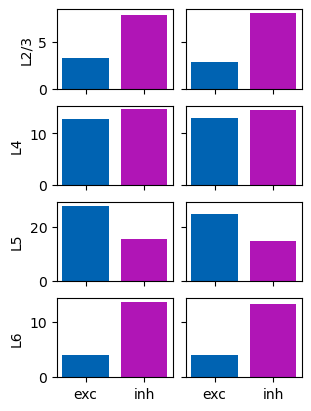

In [478]:
folder_path = '/home/samuelmr/Escritorio/results/09_28/result2_3'
t_sim = 1500
l_bin = 500

# add columns names
cols = np.array(['folder', 'layer', 'type'])
params = range(int(t_sim/l_bin))
names = np.concatenate((cols, params), axis=None)

mean_data = pd.read_csv(os.path.join(folder_path, 'mean_'+str(l_bin)+'.csv'), header=None, names=names)
bin_centers = np.linspace(l_bin/2, t_sim-(l_bin/2), int(t_sim/l_bin))
subset = mean_data[names[3:]].values


fig, ax = plt.subplots(4,2,layout='constrained', figsize=(3,4), sharex=True, sharey='row')
layer = ['L2/3','L4','L5','L6']
color = ['#0028BA','#0046B6','#0063B2','#008CAD']

for j,jj in enumerate(range(0,16,4)):

    ax[j,0].bar(0, subset[jj,1],color='#0063B2')
    ax[j,0].bar(1, subset[jj+2,1],color='#b015b6')
    ax[j,0].set_ylabel(layer[j])

    ax[j,1].bar(0, subset[jj,2],color='#0063B2')
    ax[j,1].bar(1, subset[jj+2,2],color='#b015b6')

ax[1,0].set_xticks([0,1],['exc','inh'])


# plt.xlabel('Time (ms)')
# plt.ylabel('Firing rate (Hz)')
# plt.title('PSTH L5 exc')
# plt.show()

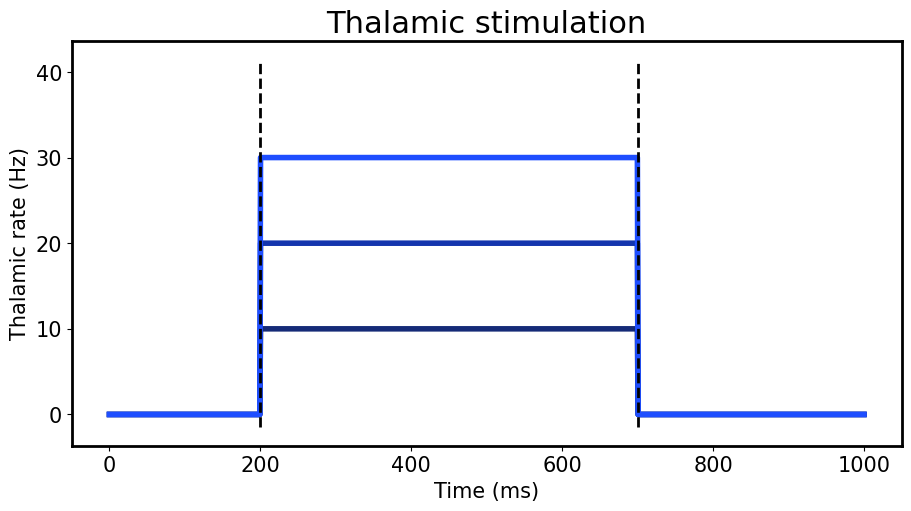

In [172]:
fig, ax = plt.subplots(layout='constrained', figsize=(9,5), sharex=True, sharey='row')

time = np.linspace(0,1000,1000)
stim1, stim2, stim3, stim4 = [], [], [], []
for i in time:
    if i >= 200 and i < 700:
        stim1.append(30)
        stim2.append(20)
        stim3.append(10)
        #stim4.append(5)
    else:
        stim1.append(0)
        stim2.append(0)
        stim3.append(0)
        #stim4.append(0)

    # if i >= 1000:
    #     stim1.append(30)
    #     #stim2.append(20)
    #     stim3.append(20)
    #     stim4.append(10)
    # else:
    #     stim1.append(0)
    #     #stim2.append(0)
    #     stim3.append(0)
    #     stim4.append(0)



color = ['#0028BA','#0046B6','#0063B2','#008CAD']
color = ['#008CAD','#0063B2','#0046B6','#0028BA']
color = ['#152A77','#1435AD','#1E4EFF'] #azul 2.0
#color = ['#112366','#152A77','#1435AD','#1E4EFF'] #azul 2.0

color2 = ['#FF0079','#BF0AFF','#5F1AFF','#1E4EFF']
color2 = ['#098A11','#00C90D','#00FF11'] #verde   

#ax.plot(time,stim4,lw=4,color=color[0]) #azul
ax.plot(time,stim3,lw=4,color=color[0]) #azul
ax.plot(time,stim2,lw=4,color=color[1]) #azul
ax.plot(time,stim1,lw=4,color=color[2]) #azul

# ax.plot(time,stim4,lw=4,color=color2[0])
# ax.plot(time,stim3,lw=4,color=color2[1])
# ax.plot(time,stim1,lw=4,color=color2[2]) #verde

bot, top = ax.get_ylim()  # return the current ylim

ax.plot([200, 200], [bot, 41.5], 'k--', lw=2)
ax.plot([700, 700], [bot, 41.5], 'k--', lw=2)

plt.xlabel('Time (ms)',fontsize=15)
plt.ylabel('Thalamic rate (Hz)',fontsize=15)
plt.title('Thalamic stimulation',fontsize=22)
#plt.xticks([0, 250, 500, 750, 1000, 1250, 1500],[0, 250, 500, 750, 1000, 1250, 1500])

plt.xticks(fontsize = 15) 
plt.yticks(fontsize = 15) 

for spine in ax.spines.values():
    spine.set_linewidth(2) 
plt.show()